# 10교시 | Visual Question Answering (VQA)
**환경**: Google Colab | **방법**: 이론 + 실습

---

## 학습 목표

- VQA(Visual Question Answering) 질문의 4단계 난이도(존재 → 속성 → 관계 → 상식 추론)를 설명할 수 있다.
- 동일한 이미지에 대해 난이도별 질문의 응답 품질 차이를 관찰한다.
- 이미지 기반 질의응답에서 Attention이 어떤 역할을 하는지 이해한다.

### 처음 읽는 분을 위한 안내

- 이번 교시를 한 줄로 보면: 이미지를 보고 질문에 맞는 답을 만드는 과정이 단순 분류보다 왜 더 어려운지 배우는 시간이다.
- 처음에는 여기까지 이해하면 충분하다: `무엇이 있는가`보다 `왜 그렇게 보이는가`가 더 어려운 질문이라는 정도만 구분해도 된다.
- 헷갈려도 괜찮은 부분: Level 1~5 구분이 처음엔 비슷해 보여도 괜찮다. 실습 결과를 보면서 존재/속성/관계/추론 차이를 체감하면 된다.

### 용어 미니사전

| 용어 | 아주 쉽게 말하면 |
|---|---|
| VQA(Visual Question Answering) | 이미지를 보고 질문에 답하는 작업 |
| 존재 질문 | 무엇이 있는지 묻는 가장 쉬운 질문 |
| 속성 질문 | 색, 모양, 재질처럼 특징을 묻는 질문 |
| 관계 질문 | 어디에 있는지, 무엇과 연결되는지 묻는 질문 |
| 상식 추론 | 이미지 바깥의 일반 지식까지 끌어와 답하는 단계 |
| Persona | 같은 이미지도 다른 말투와 관점으로 설명하게 하는 역할 설정 |

---

## 이론

### 먼저 큰 그림부터 이해하기

VQA는 한 문장으로 말하면, **이미지를 보고 질문에 맞게 답하는 작업**이다.  
겉보기에는 단순해 보이지만, 실제로는 세 가지가 동시에 필요하다.

1. 이미지 안에 무엇이 있는지 알아보는 시각 이해
2. 질문이 무엇을 요구하는지 파악하는 언어 이해
3. 둘을 연결해 맞는 답을 만드는 추론

그래서 VQA는 단순 이미지 분류보다 훨씬 어렵다. 분류는 보통 `이 이미지가 무엇인가`를 한 번 답하면 끝나지만, VQA는 `무엇이 있는가`, `무슨 색인가`, `어디에 있는가`, `왜 그렇게 보이는가`처럼 질문마다 필요한 정보가 달라진다.

### VQA(Visual Question Answering)란?

- **입력**: 이미지 + 자연어 질문
- **출력**: 자연어 답변
- 단순 분류(선택지)에서 오픈 엔드 생성 방식으로 발전

즉, VQA는 이미지에 대해 정답 레이블 하나를 뽑는 문제가 아니라, **질문 조건에 맞는 정보를 골라 언어로 답하는 문제**다. 같은 이미지라도 질문이 바뀌면 모델이 주목해야 할 영역과 필요한 추론 방식이 달라진다.

### 질문 유형별 난이도

| 단계 | 유형 | 예시 질문 | 필요 능력 |
|---|---|---|---|
| Level 1 | 존재 여부 | "이미지에 꽃이 있나요?" | 기본 객체 인식 |
| Level 2 | 속성 인식 | "꽃의 색깔은 무엇인가요?" | 세밀한 시각 특징 |
| Level 3 | 관계/공간 | "앞쪽과 뒤쪽에 무엇이 있나요?" | 공간적 이해 |
| Level 4 | 상식 추론 | "이 사람은 어떤 기분일까요?" | 상식 + 감정 이해 |
| Level 5 | 복합 추론 | "이 문화권은 어디일까요? 근거는?" | 다중 단서 종합 |

이 표를 읽을 때 중요한 것은, 레벨이 올라갈수록 단순히 질문이 길어지는 것이 아니라 **모델이 이미지 밖의 지식까지 더 많이 끌어와야 한다**는 점이다.  
Level 1 ~ 2는 이미지에 직접 보이는 정보만으로 해결되는 경우가 많지만, Level 4 ~ 5는 상식, 문화 맥락, 추정이 함께 필요해져 오류 가능성도 커진다.

### VQA에서 Attention의 역할

텍스트 쿼리("빨간 꽃이 몇 개인가요?")가 이미지의 특정 패치 영역에 더 높은 Attention을 부여한다.

```
질문: "빨간 꽃이 몇 개인가요?"
  ↓ 텍스트 임베딩
모델이 이미지 패치 중 "빨간 영역"에 집중
  ↓ Attention 가중치가 해당 패치에 높게 할당
"3개"라는 답변 생성
```

Cross-Attention 또는 이미지·텍스트 토큰 간 Self-Attention으로 구현된다.

이 개념을 직관적으로 말하면, 질문은 일종의 "탐색 지시문" 역할을 한다.  
`빨간 꽃이 몇 개인가요?`라고 물으면 모델은 전체 이미지를 똑같이 보는 것이 아니라, `빨간`, `꽃`, `개수`와 관련된 영역에 더 집중해야 한다. 그래서 VQA에서는 질문과 이미지 패치가 어떻게 연결되는지가 매우 중요하다.

### GPT-4V/4.1-mini의 VQA 능력

- **텍스트 이해**: 이미지 내 글자, 수식, 코드 인식
- **공간 관계**: 객체 간 위치 관계 (위/아래, 왼쪽/오른쪽) 상대위치(RoPE)  
- **세밀한 속성**: 색상, 모양, 재질, 표정
- **문화적 맥락**: 음식, 의상, 건축물 등 문화 특징 인식

다만 이런 능력이 있다고 해서 항상 완벽한 것은 아니다. 특히 상식 추론이나 문화적 해석은 이미지에 직접 보이지 않는 부분까지 추정해야 하므로, 모델이 그럴듯하지만 틀린 답을 만들 수 있다. 따라서 VQA 결과를 볼 때는 `맞는가`뿐 아니라 `어디까지는 관찰이고 어디부터는 추론인가`를 구분해서 읽는 습관이 중요하다.

### 입력에서 출력까지 한 번에 보기

VQA의 내부 흐름은 아래처럼 이해하면 된다.

```
이미지
    ↓ Vision Encoder
이미지 토큰/임베딩

질문 문장
    ↓ Tokenization
텍스트 토큰

이미지와 질문을 함께 조건으로 사용
    ↓ Attention으로 관련 영역 선택
답변 토큰을 한 개씩 생성
```

즉, VQA는 `이미지 인식 + 질의응답`이 단순히 나란히 붙은 것이 아니라, 질문이 이미지 해석 방식을 바꾸고 그 결과가 다시 답변 생성에 영향을 주는 구조다.

### 이론을 읽을 때 꼭 잡아야 할 연결 고리

이 단원에서는 아래 흐름이 연결되어야 한다.

1. VQA는 이미지와 질문을 함께 이해해야 한다.
2. 질문 난이도가 올라갈수록 필요한 능력이 객체 인식에서 추론으로 이동한다.
3. Attention은 질문과 관련된 이미지 영역을 연결하는 핵심 장치다.
4. 그래서 Level 1 ~ 3보다 Level 4 ~ 5에서 오류와 불확실성이 더 늘어난다.
5. 시스템 프롬프트는 같은 시각 정보도 다른 관점과 말투로 표현하게 만든다.

---

## 실습

### 자주 막히는 오류

- Level 2와 Level 3가 비슷해 보임: 속성은 대상 자체 특징, 관계는 대상들 사이 위치와 연결이라고 구분하면 쉽다.
- 답이 길다고 더 정확한 것은 아님: 특히 Level 4~5는 그럴듯하지만 추정이 섞일 수 있다.
- 시스템 프롬프트 차이가 작게 느껴짐: 질문이 너무 단순하면 말투 변화가 크게 안 드러날 수 있다.
- 이미지 기반 답변과 상식 기반 답변이 섞임: 어디까지가 관찰이고 어디부터가 추론인지 따로 읽어보는 습관이 중요하다.

### 실패했을 때 체크 순서

1. 지금 질문이 존재, 속성, 관계, 추론 중 어디에 속하는지 먼저 분류한다.
2. 답변에서 관찰과 추정을 분리해서 읽는다: 이미지에서 보이는 것과 상식으로 보태는 것을 따로 본다.
3. 더 쉬운 질문으로 한 단계 내려간다: Level 4가 막히면 Level 2~3 질문으로 다시 비교해 기반을 잡는다.

실습은 아래 순서대로 **한 단계씩 실행**하는 것을 권장한다.  
이번 차시의 실습은 크게 세 부분이다.

1. VQA 실험을 위한 이미지 인코딩 함수와 질문 함수 준비
2. 두 장의 이미지에 대해 난이도별 질문을 던져 답변 비교
3. 시스템 프롬프트에 따라 답변 스타일이 어떻게 달라지는지 확인

각 코드 블록은 바로 위 설명과 연결되므로, 한 셀을 실행한 뒤 출력 결과를 확인하고 다음 셀로 넘어가면 된다.

### Step 0. VQA 실습 준비

먼저 이미지를 base64로 바꾸는 함수와, 이미지+질문을 함께 보내는 `vqa()` 함수를 만든다.

In [2]:
import base64
import requests
import matplotlib.pyplot as plt
from io import BytesIO
from PIL import Image
from openai import OpenAI
from google.colab import userdata

api_key = userdata.get("OPENAI_API_KEY")
if not api_key:
  raise ValueError("Colab Secrets에 OPENAI_API_KEY를 먼저 등록하세요.")

client = OpenAI(api_key=api_key)

def image_url_to_b64(url: str, max_size: int = 512) -> str:
  response = requests.get(
    url,
    headers={"User-Agent": "Mozilla/5.0"},
    timeout=20,
  )
  response.raise_for_status()

  content_type = response.headers.get("Content-Type", "")
  if not content_type.startswith("image/"):
    raise ValueError(f"이미지 URL이 아닙니다: {url} (Content-Type: {content_type})")

  img = Image.open(BytesIO(response.content)).convert("RGB")

  # 너무 큰 이미지는 축소해 API 비용을 줄인다.
  if max(img.size) > max_size:
    ratio = max_size / max(img.size)
    new_size = (int(img.size[0] * ratio), int(img.size[1] * ratio))
    img = img.resize(new_size, Image.LANCZOS)

  buf = BytesIO()
  img.save(buf, format="JPEG", quality=85)
  return base64.b64encode(buf.getvalue()).decode(), img

def vqa(b64: str, question: str, system: str = "You are a helpful vision assistant.", max_tokens: int = 250) -> str:
    resp = client.chat.completions.create(
        model="gpt-4.1-mini",
        messages=[
            {"role": "system", "content": system},
            {"role": "user", "content": [
                {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{b64}"}},
                {"type": "text", "text": question},
            ]},
        ],
        max_tokens=max_tokens,
    )
    return resp.choices[0].message.content



이 단계에서 확인할 점:

- VQA도 결국 이미지+텍스트를 함께 API에 보내는 구조라는 점 이해
- `system` 프롬프트도 함께 제어할 수 있다는 점 확인

### Step 1. 꽃 관련 이미지로 난이도별 질문 실험

먼저 꽃 관련 이미지를 대상으로 Level 1~5 질문을 순서대로 실험한다.

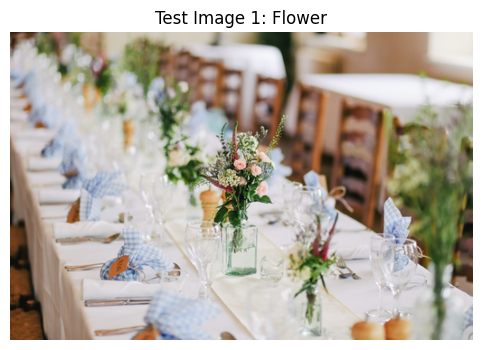


[Level 1 — 존재]
Q: 이 이미지에는 어떤 종류의 꽃들이 보이나요?
A: 이 이미지에는 작은 분홍색과 흰색 꽃들이 보이고, 초록색 잎과 함께 꽃병에 꽂혀 있습니다. 주로 작은 장미꽃과 비슷한 꽃, 그리고 갈대나 야생화 같은 식물들도 포함되어 있습니다. 정확한 꽃 종류는 화질과 각도 때문에 확실하지 않지만, 장미류와 야생화가 조화롭게 배치된 장식으로 보입니다.

[Level 2 — 속성]
Q: 이 이미지에서 가장 두드러지는 색상은 무엇인가요?
A: 이 이미지에서 가장 두드러지는 색상은 흰색(테이블보)과 연한 파란색(냅킨)입니다. 또한 초록색(꽃병과 식물)과 분홍색(꽃)도 눈에 띕니다.

[Level 3 — 공간]
Q: 이 이미지의 앞쪽과 뒤쪽에서 어떤 장면이 보이는지 설명해 주세요.
A: 이 이미지는 긴 식탁이 흰 식탁보로 덮여 있고, 앞쪽과 뒤쪽 모두 여러 개의 의자가 가지런히 놓여 있는 모습을 보여줍니다. 식탁 위에는 꽃병에 담긴 다양한 꽃들이 일정한 간격으로 배치되어 있어 장식된 파티나 연회 같은 분위기를 연출합니다. 와인잔과 접시, 그리고 냅킨, 식기류 등이 정갈하게 세팅되어 있으며, 앞쪽 끝부분에 초록색 꽃병에 꽃다발이 좀 더 가까이 보입니다. 뒤쪽으로는 더 많은 꽃병과 의자가 줄지어 보이고, 배경이 살짝 흐릿해져 있어 식당이나 행사장 내부의 따뜻하고 정돈된 분위기를 느낄 수 있습니다.

[Level 4 — 추론]
Q: 이 장면은 하루 중 어느 시간대로 보이나요? 보이는 시각적 단서를 근거로 설명해 주세요.
A: 이 장면은 낮 시간대로 보입니다. 시각적 단서로는 테이블 위와 주변 공간이 자연광으로 밝게 비춰져 있다는 점이 있습니다. 창문이나 개방된 공간에서 들어오는 빛이 따뜻하고 은은하며, 그림자가 강하지 않아 중간 정도 밝기인 낮 시간임을 알 수 있습니다. 또한 조명 장치가 켜져 있지 않아도 충분히 밝은 점도 낮 시간대임을 뒷받침합니다.

[Level 5 — 복합]
Q: 이 이미지에서 추론할 수 있는 문화적, 경제적 맥락을 설명하고, 이 장

In [6]:
flower_url = "https://images.unsplash.com/photo-1519225421980-715cb0215aed?auto=format&fit=crop&w=1200&q=80"
b64_flower, img_flower = image_url_to_b64(flower_url)

plt.figure(figsize=(6, 4))
plt.imshow(img_flower)
plt.axis("off")
plt.title("Test Image 1: Flower")
plt.show()

questions = [
  ("Level 1 — 존재", "이 이미지에는 어떤 종류의 꽃들이 보이나요?"),
  ("Level 2 — 속성", "이 이미지에서 가장 두드러지는 색상은 무엇인가요?"),
  ("Level 3 — 공간", "이 이미지의 앞쪽과 뒤쪽에서 어떤 장면이 보이는지 설명해 주세요."),
  ("Level 4 — 추론", "이 장면은 하루 중 어느 시간대로 보이나요? 보이는 시각적 단서를 근거로 설명해 주세요."),
    ("Level 5 — 복합", "이 이미지에서 추론할 수 있는 문화적, 경제적 맥락을 설명하고, 이 장소가 어느 지역인지 근거를 들어 추론해 주세요."),
]

print("=" * 65)

for level_name, question in questions:
    answer = vqa(b64_flower, question)
    print(f"\n[{level_name}]")
    print(f"Q: {question}")
    print(f"A: {answer}")



이 단계에서 확인할 점:

- 쉬운 질문(Level 1 ~ 2)과 어려운 질문(Level 4 ~ 5)의 답변 난이도가 달라지는가?
- 추론 질문으로 갈수록 불확실한 표현이 늘어나는가?

### Step 2. 개미 이미지로 난이도별 질문 실험

이번에는 개미 근접 사진에 대해 난이도별 질문을 던져 본다.

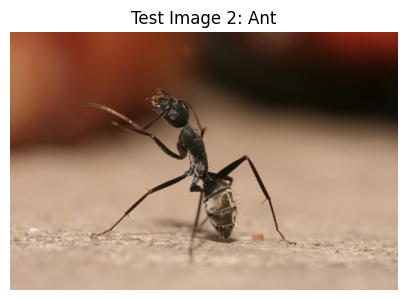



[Level 1 — 존재]
Q: 이 이미지에는 어떤 곤충이 보이나요?
A: 이 이미지에는 개미가 보입니다.

[Level 2 — 속성]
Q: 이 이미지에서 보이는 개미의 외형적 특징을 설명해 주세요. 색깔, 몸의 부분, 질감을 함께 말해 주세요.
A: 이 이미지에서 보이는 개미는 다음과 같은 외형적 특징을 가지고 있습니다:

- 색깔: 검은색을 주로 띠고 있으며, 배 부분은 다소 밝은 회색빛을 띠고 있습니다.
- 몸의 부분: 개미의 머리, 가슴, 배 세 부분이 분명히 나누어져 있습니다. 머리에는 더듬이가 두 개 길게 뻗어 있고, 다리도 여섯 개가 보입니다. 다리는 길고 가늘며 관절이 뚜렷합니다.
- 질감: 몸 전체가 매끄럽고 광택이 있는 질감으로 보이며, 특히 가슴과 배 부분이 약간 윤기가 있는 표면으로 나타납니다.

전체적으로 길고 가느다란 다리와 뚜렷한 몸 부분 구분이 특징적이고, 어두운 색조가 눈에 띄는 개미입니다.

[Level 3 — 관계]
Q: 이 개미는 무엇을 하고 있는 것처럼 보이나요? 그리고 어떤 표면 위에 있나요?
A: 이 개미는 앞다리를 들어 올리고 있는 모습으로 보입니다. 이는 경계하거나 주의를 기울이는 행동일 수 있습니다. 개미가 서 있는 표면은 거칠거나 마른 흙이나 모래와 비슷한 질감의 땅 위로 보입니다.

[Level 4 — 과학적]
Q: 과학적인 관점에서 볼 때, 이 개미는 어떤 종일 가능성이 있나요? 그리고 어떤 행동 단서를 관찰할 수 있나요?
A: 이 사진에 나온 개미는 몸체와 다리의 형태, 크기 비율로 보아, 과학적인 관점에서 볼 때, Camponotus(콩포노투스)속 개미일 가능성이 큽니다. 이 속은 일반적으로 "큰개미" 혹은 "장수개미"라 불리며, 크고 튼튼한 몸체가 특징입니다.

사진에서 관찰되는 행동 단서를 보면, 개미가 앞다리를 들어 올리고, 몸을 거의 수직으로 세우며 경계하거나 방어 자세를 취하는 모습으로 보입니다. 이러한 행동은 다음과 같은 의미일 수 있습니다:
- 공격적이거나 방어적인 자세로, 위협을 느끼고 

In [8]:
ant_url = "https://upload.wikimedia.org/wikipedia/commons/a/a7/Camponotus_flavomarginatus_ant.jpg"
b64_ant, img_ant = image_url_to_b64(ant_url)

plt.figure(figsize=(5, 4))
plt.imshow(img_ant)
plt.axis("off")
plt.title("Test Image 2: Ant")
plt.show()

questions_ant = [
  ("Level 1 — 존재", "이 이미지에는 어떤 곤충이 보이나요?"),
  ("Level 2 — 속성", "이 이미지에서 보이는 개미의 외형적 특징을 설명해 주세요. 색깔, 몸의 부분, 질감을 함께 말해 주세요."),
  ("Level 3 — 관계", "이 개미는 무엇을 하고 있는 것처럼 보이나요? 그리고 어떤 표면 위에 있나요?"),
  ("Level 4 — 과학적", "과학적인 관점에서 볼 때, 이 개미는 어떤 종일 가능성이 있나요? 그리고 어떤 행동 단서를 관찰할 수 있나요?"),
    ("Level 5 — 복합", "이 사진에서 관찰되는 개미의 특징을 바탕으로, 이 개미의 생태적 역할과 특이한 점을 한국어로 설명해 주세요."),
]

print("\n" + "=" * 65)

for level_name, question in questions_ant:
    answer = vqa(b64_ant, question)
    print(f"\n[{level_name}]")
    print(f"Q: {question}")
    print(f"A: {answer}")



이 단계에서 확인할 점:

- 존재/속성 질문은 비교적 안정적으로 답하는가?
- 과학적 추론으로 갈수록 답변에 추정이나 불확실성이 포함되는가?

### Step 3. 시스템 프롬프트에 따른 답변 차이 보기

같은 이미지와 같은 질문이라도, 시스템 프롬프트를 바꾸면 답변 스타일이 어떻게 달라지는지 확인한다.

In [9]:
print("\n" + "=" * 65)
print("[시스템 프롬프트에 따른 답변 차이]")
print("=" * 65)

question_common = "이 이미지에서 가장 흥미로운 점은 무엇인가요?"

system_prompts = {
    "일반 어시스턴트": "You are a helpful assistant. Answer in Korean.",
    "초등학생 교사": "You are a teacher explaining things to elementary school students. Use simple Korean.",
    "과학자": "You are a research scientist. Provide a detailed technical analysis in Korean.",
    "여행 가이드": "You are a travel guide with deep knowledge of culture. Answer in Korean.",
}

for persona, sys_prompt in system_prompts.items():
    answer = vqa(b64_flower, question_common, system=sys_prompt, max_tokens=150)
    print(f"\n[{persona}]")
    print(answer)


[시스템 프롬프트에 따른 답변 차이]

[일반 어시스턴트]
이 이미지에서 가장 흥미로운 점은 매우 정성스럽게 꾸며진 테이블 세팅입니다. 깔끔한 흰색 식탁보 위에 유리잔, 꽃병에 담긴 신선한 꽃들, 그리고 체크무늬 냅킨들이 차분하면서도 세련된 분위기를 자아냅니다. 특히, 길게 늘어진 테이블에 일렬로 배치된 장식들이 행사나 결혼식과 같은 특별한 모임을 준비하는 듯한 느낌을 줍니다. 이런 섬세한 디테일이 시선을 끄는 가장 큰 요소 같습니다.

[초등학생 교사]
이 이미지에서 가장 흥미로운 점은 예쁜 꽃들이 테이블 위에 여러 개 놓여 있다는 거예요. 그리고 접시, 물컵, 포크, 나이프 등이 잘 정리되어 있어서 파티나 특별한 모임을 준비한 것처럼 보여요. 테이블이 길게 이어져 있어서 많은 사람들이 함께 모일 것 같아요. 아주 아름답고 깔끔한 모습이 참 멋져 보입니다!

[과학자]
이 이미지에서 가장 흥미로운 점은 정갈하고 세심하게 꾸며진 테이블 세팅과 꽃 장식입니다. 특히, 각 자리마다 체크 무늬의 냅킨이 가지런히 접혀 놓여 있고, 중앙에 배치된 투명 유리병에 담긴 다양한 색상의 생화들이 전체적인 분위기를 부드럽고 생기 있게 만들어줍니다. 

이러한 세팅은 아마도 결혼식, 연회 또는 특별한 이벤트를 위한 것으로 보이며, 테이블이 길게 늘어져 있어 많은 인원이 함께하는 자리임을 시사합니다. 또한, 자연광이 부드럽게 들어와 전체적인 색감과 분위

[여행 가이드]
이 이미지에서 가장 흥미로운 점은 식탁이 정성스럽게 꾸며져 있다는 점입니다. 흰색 테이블보 위에 꽃병에 담긴 신선한 꽃들이 놓여 있어 분위기가 매우 우아하고 세련되게 느껴집니다. 또한, 와인잔과 냅킨이 정갈하게 준비되어 있어 특별한 행사나 연회, 결혼식 같은 중요한 자리임을 암시합니다. 다 같이 둘러앉아 즐거운 시간을 보낼 수 있을 것 같은 따뜻하고 환영하는 공간이라는 점이 특히 눈에 띕니다.




이 단계에서 확인할 점:

- 같은 이미지라도 설명의 관점과 어휘 수준이 달라지는가?
- 시스템 프롬프트가 응답 스타일에 큰 영향을 주는가?

### 실습을 마친 뒤 정리

위 실습이 끝나면 아래 내용을 말로 설명할 수 있어야 한다.

1. VQA는 이미지 이해와 자연어 질의응답이 결합된 작업이다.
2. 질문 난이도가 올라갈수록 모델은 더 복잡한 추론을 요구받는다.
3. 쉬운 시각 질문은 비교적 안정적이지만, 상식/문화 추론은 더 어려울 수 있다.
4. 같은 이미지라도 질문 방식과 시스템 프롬프트에 따라 답변이 달라진다.
5. VQA는 단순 객체 인식이 아니라 공간 관계와 추론 능력까지 포함한다.

**관찰 과제**

1. Level 1~5로 갈수록 답변의 복잡도와 정확도가 어떻게 변하는지 기록
2. Level 4(상식 추론)에서 모델이 틀리거나 불확실한 경우는 어떤 패턴인지 관찰
3. 동일한 이미지에 대해 페르소나(시스템 프롬프트)에 따라 답변이 얼마나 다른지 비교

---

## 핵심 개념 정리

```
VQA = 이미지 이해 + 자연어 질의 응답

난이도 계층:
  존재 → 속성 → 관계/공간 → 상식 추론 → 복합 추론

현재 GPT-4.1-mini 수준:
  Level 1~3: 대부분 정확
  Level 4~5: 충분히 잘하지만 복잡한 문화적 추론에서 오류 발생 가능
  
다음 교시에서 실습할 Qwen3-VL의 한국어 능력과 비교해볼 것
```

### 혼자 점검하기

아래 질문에 막힘 없이 답하면 이론 이해가 잘 된 것이다.

1. VQA는 단순 이미지 분류와 무엇이 다른가?
2. Level 1~5 질문은 각각 어떤 종류의 능력을 요구하는가?
3. VQA에서 Attention은 왜 중요한가?
4. Level 4~5로 갈수록 답변이 어려워지는 이유는 무엇인가?
5. 시스템 프롬프트가 VQA 응답 스타일에 영향을 주는 이유는 무엇인가?

---

## 다음 교시 예고

**11교시**: RunPod JupyterLab으로 환경을 전환하고, Qwen3-VL 아키텍처를 심층 설명한 뒤 모델 로딩 및 환경 설정을 완료한다.

---

## 부록 | 관찰 과제·혼자 점검 모범 답안

이 부록은 교육생이 실습과 이론을 마친 뒤 스스로 이해를 점검할 수 있도록 만든 해설이다.  
정답을 그대로 외우기보다, **질문 난이도와 답변 변화를 보고 왜 그런 차이가 생기는지 설명할 수 있는지**를 기준으로 활용하면 된다.

### 관찰 과제 모범 답안

**1. Level 1~5로 갈수록 답변의 복잡도와 정확도가 어떻게 변하는지 기록**

일반적으로 Level 1~2는 존재 여부와 속성 인식이 중심이어서 비교적 정확하고 간결한 답변이 나온다. Level 3은 공간 관계가 추가되어 설명이 조금 더 길어진다. Level 4~5는 상식, 문화, 맥락 추론이 필요하므로 답변이 더 복잡해지지만, 동시에 불확실성이나 오류 가능성도 커진다. 즉, 난이도가 올라갈수록 답변은 풍부해지지만 정확도는 더 흔들릴 수 있다.

**2. Level 4(상식 추론)에서 모델이 틀리거나 불확실한 경우는 어떤 패턴인지 관찰**

보통 이미지에 직접 보이는 정보만으로는 충분하지 않고, 외부 상식이나 문화적 맥락이 필요할 때 오류가 생기기 쉽다. 예를 들어 시간대, 분위기, 문화권 추정처럼 이미지 바깥의 지식을 끌어와야 하는 질문은 모델이 추정성 답변을 하거나 자신 있게 틀릴 수 있다. 이 패턴은 VQA가 단순 시각 인식을 넘어 추론 문제라는 점을 보여준다.

**3. 동일한 이미지에 대해 페르소나(시스템 프롬프트)에 따라 답변이 얼마나 다른지 비교**

같은 이미지와 같은 질문이라도, 시스템 프롬프트에 따라 답변 어휘, 길이, 설명 수준, 강조 포인트가 달라진다. 초등학생 교사 역할은 쉽고 짧게 설명하고, 과학자 역할은 더 분석적이고 전문적으로 설명하려는 경향이 있다. 즉, 시스템 프롬프트는 이미지 이해 자체를 바꾸기보다, 그 이해를 어떤 방식으로 표현할지를 크게 바꾼다.

### 혼자 점검하기 모범 답안

**1. VQA는 단순 이미지 분류와 무엇이 다른가?**

이미지 분류는 주로 한 장의 이미지에 대해 하나의 레이블을 예측하는 작업이다. 반면 VQA는 이미지와 자연어 질문을 함께 받아, 질문에 맞는 자연어 답변을 생성해야 한다. 즉, VQA는 이미지 이해뿐 아니라 언어 이해와 질의응답 능력이 함께 필요하다.

**2. Level 1~5 질문은 각각 어떤 종류의 능력을 요구하는가?**

- Level 1: 객체가 있는지 인식하는 능력
- Level 2: 색상, 모양, 질감 같은 속성 인식 능력
- Level 3: 위치와 관계를 이해하는 공간적 능력
- Level 4: 상식과 맥락을 활용하는 추론 능력
- Level 5: 여러 단서를 종합하는 복합 추론 능력

즉, 레벨이 올라갈수록 단순 시각 인식에서 추론 중심 작업으로 넘어간다.

**3. VQA에서 Attention은 왜 중요한가?**

질문이 어떤 대상이나 속성을 묻는지에 따라, 모델이 이미지의 특정 패치나 영역에 더 집중해야 하기 때문이다. 예를 들어 `빨간 꽃`을 묻는다면 관련 패치에 더 큰 attention이 가야 정확한 답변을 만들 수 있다. 따라서 Attention은 질문과 이미지 영역을 연결하는 핵심 메커니즘이다.

**4. Level 4~5로 갈수록 답변이 어려워지는 이유는 무엇인가?**

Level 4~5는 이미지에 직접 보이는 정보만으로 충분하지 않고, 상식, 문화, 맥락, 복수 단서 통합이 필요하기 때문이다. 즉, 단순히 `무엇이 보이는가`를 넘어서 `왜 그런가`, `어디일 가능성이 큰가`, `어떤 의미가 있는가`까지 요구한다. 그래서 오류 가능성도 함께 커진다.

**5. 시스템 프롬프트가 VQA 응답 스타일에 영향을 주는 이유는 무엇인가?**

시스템 프롬프트는 모델이 답변을 어떤 관점과 말투로 생성할지를 정하는 초기 맥락이다. 이미지 이해 결과가 같더라도, 이를 쉬운 말로 풀지, 과학적으로 분석할지, 문화적으로 해석할지는 시스템 프롬프트에 따라 달라질 수 있다.

### 활용 팁

이 부록은 아래 순서로 복습할 때 가장 효과적이다.

1. 먼저 각 레벨 질문의 답변을 읽고 스스로 난이도 차이를 설명해 본다.
2. 그다음 모범 답안과 비교한다.
3. 표현이 조금 달라도 핵심 차이를 설명하면 이해한 것으로 본다.
4. 설명이 막히면 질문 유형(Level 1~5) 정의를 다시 확인한다.